### Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("../../build-release").resolve()))

import mpcd_cpp as mpcd

import numpy as np
import matplotlib.pyplot as plt


### Parameters of Simulation

In [362]:
params = {
    "box": np.array([10.0, 10.0, 10.0]),

    # MPCD solvent
    "n_solvent": 5000,
    "solvent_mass": 1.0,
    "a": 1.0,
    "h": 0.1,
    "alpha": np.pi / 2,
    "kBT": 0.75,

    # Polymer
    "n_monomers": 30,
    "polymer_mass": 3.0,
    "bond_length": 0.5,
    "k_bond": 100.0,

    # Sampling
    "sample_every": 1,
    "frame_every": 10,
    "bond_vector_every": 10,

    # MD
    "n_md_substeps": 500,
    "n_mpcd_steps": 1000,

    # Random seed
    "seed": 42,
}
dt_md = params["h"] / params["n_md_substeps"]

In [363]:
print(f"MD timestep: {dt_md}")
print(f"MD substeps per MPCD step: {params['n_md_substeps']}")
print(f"Total simulated time: {params['n_mpcd_steps'] * params['h']}")

MD timestep: 0.0002
MD substeps per MPCD step: 500
Total simulated time: 100.0


### Creation of a Polymer and a System

In [364]:
system = mpcd.System(
    params["n_solvent"],
    params["box"],
    params["a"],
    params["h"],
    params["solvent_mass"],
    params["kBT"],
    params["alpha"],
    params["seed"]
)

polymer = mpcd.Polymer(
    params["n_monomers"],
    params["box"],
    dt_md,
    params["bond_length"],
    params["polymer_mass"],
    params["k_bond"],
    params["kBT"],
    params["seed"] + 1
)

system.initPositionsUniform()
system.initVelocitiesNormal()

polymer.initPositionsRandomWalk()
polymer.initVelocitiesNormal()

### Simulation

In [365]:
samples = mpcd.runCoupled(
    system,
    polymer,
    params["n_mpcd_steps"],
    params["sample_every"],
    params["frame_every"],
    params["bond_vector_every"]
)

### Results


In [366]:
history = {
    "step": np.asarray(samples.polymer.steps),

    "polymer_K": np.asarray(samples.polymer.kineticEnergy),
    "polymer_U": np.asarray(samples.polymer.potentialEnergy),
    "polymer_E": np.asarray(samples.polymer.totalEnergy),

    "mean_bond_length": np.asarray(samples.polymer.averageBondLength),
    "max_bond_length": np.asarray(samples.polymer.maxBondLength),

    "polymer_momentum": np.asarray(samples.polymer.momentum),

    "solvent_K": np.asarray(samples.solvent.kineticEnergy),
    "solvent_T": np.asarray(samples.solvent.temperature),
    "solvent_momentum": np.asarray(samples.solvent.momentum),
}

### Sanity checks

#### Total energy

In [367]:
history["combined_E"] = history["solvent_K"] + history["polymer_E"]

relative_combined_E = (history["combined_E"] - history["combined_E"][0]) / history["combined_E"][0]

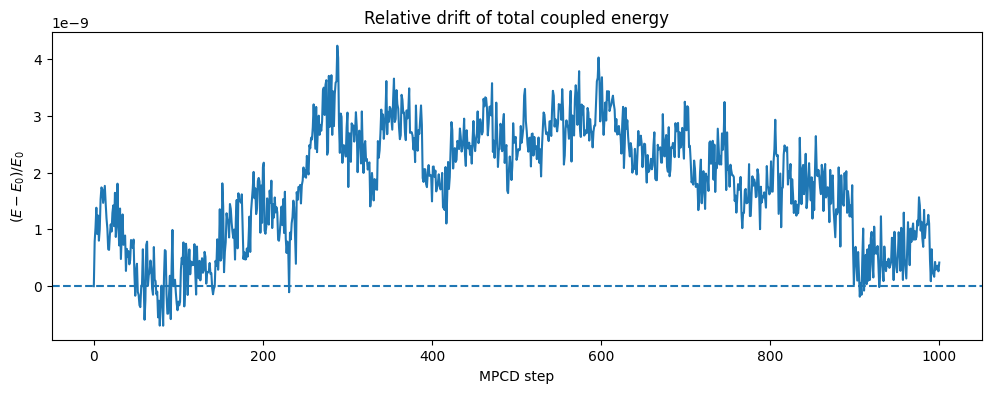

Maximum relative energy deviation: 4.234405991721542e-09


In [368]:
plt.figure(figsize=(12, 4))
plt.plot(history["step"], relative_combined_E)
plt.axhline(0, linestyle="--")
plt.xlabel("MPCD step")
plt.ylabel(r"$(E-E_0)/E_0$")
plt.title("Relative drift of total coupled energy")
plt.show()

print("Maximum relative energy deviation:",np.max(np.abs(relative_combined_E)))

#### Momentum

In [369]:
history["P_total"] = history["polymer_momentum"] + history["solvent_momentum"]

delta_P_total = np.linalg.norm(history["P_total"] - history["P_total"][0], axis=1)

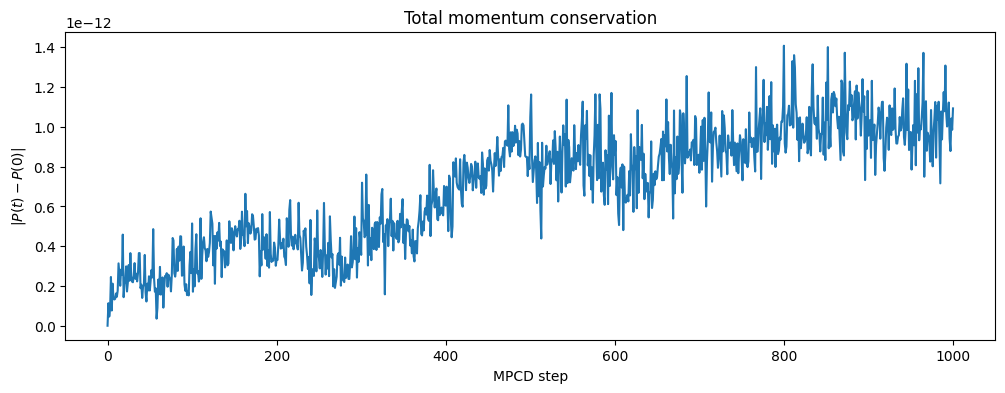

In [370]:
plt.figure(figsize=(12, 4))
plt.plot(history["step"], delta_P_total)
plt.xlabel("MPCD step")
plt.ylabel(r"$|P(t)-P(0)|$")
plt.title("Total momentum conservation")
plt.show()

#### Temperature

In [371]:
P2 = np.sum(history["polymer_momentum"]**2, axis=1)

K_com = P2 / (2.0*params["n_monomers"]*params["polymer_mass"])

K_internal = history["polymer_K"] - K_com

T_polymer = (2.0 * K_internal/(3.0*(params["n_monomers"] - 1)))

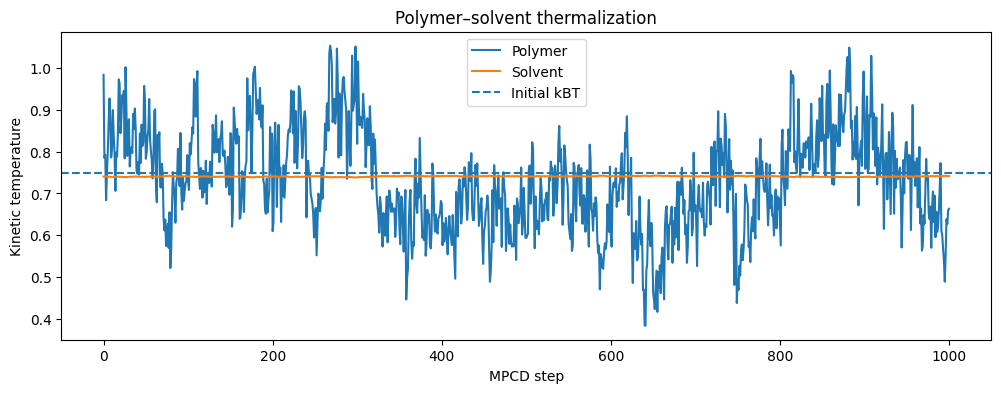

Polymer mean T: 0.7102617279156073
Solvent mean T: 0.7409269460957433
Polymer std: 0.11817764441002684
Solvent std: 0.000785605836265098


In [372]:
plt.figure(figsize=(12, 4))

plt.plot(
    history["step"],
    T_polymer,
    label="Polymer"
)

plt.plot(
    history["step"],
    history["solvent_T"],
    label="Solvent"
)

plt.axhline(
    params["kBT"],
    linestyle="--",
    label="Initial kBT"
)

plt.xlabel("MPCD step")
plt.ylabel("Kinetic temperature")
plt.title("Polymer–solvent thermalization")
plt.legend()
plt.show()

equilibrium_start = len(history["step"]) // 2

print(
    "Polymer mean T:",
    T_polymer[equilibrium_start:].mean()
)

print(
    "Solvent mean T:",
    history["solvent_T"][equilibrium_start:].mean()
)

print(
    "Polymer std:",
    T_polymer[equilibrium_start:].std()
)

print(
    "Solvent std:",
    history["solvent_T"][equilibrium_start:].std()
)

#### Energy per parcticle

In [373]:
polymer_E_per_particle = ( history["polymer_E"] / params["n_monomers"])
solvent_K_per_particle = (history["solvent_K"] / params["n_solvent"])

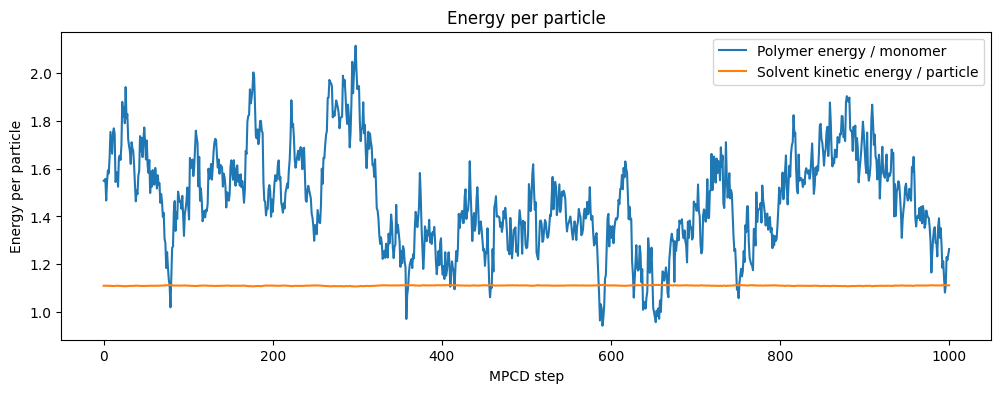

In [374]:
plt.figure(figsize=(12, 4))

plt.plot(
    history["step"],
    polymer_E_per_particle,
    label="Polymer energy / monomer"
)

plt.plot(
    history["step"],
    solvent_K_per_particle,
    label="Solvent kinetic energy / particle"
)

plt.xlabel("MPCD step")
plt.ylabel("Energy per particle")
plt.title("Energy per particle")
plt.legend()
plt.show()

#### Relative polymer-energy fluctuations

In [375]:
E_eq = history["polymer_E"][equilibrium_start:]

relative_polymer_E = (
    history["polymer_E"] - E_eq.mean()
) / E_eq.mean()

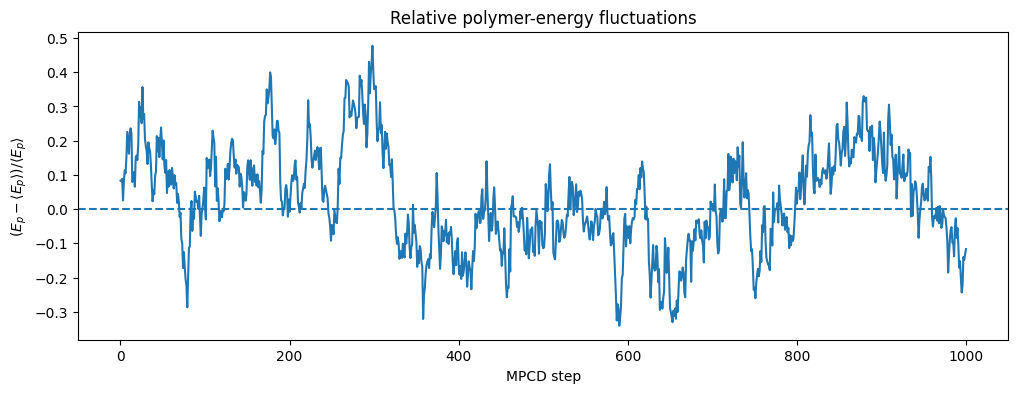

Relative polymer energy std: 0.13694804845962297


In [376]:
plt.figure(figsize=(12, 4))
plt.plot(history["step"], relative_polymer_E)
plt.axhline(0, linestyle="--")
plt.xlabel("MPCD step")
plt.ylabel(r"$(E_p-\langle E_p\rangle)/\langle E_p\rangle$")
plt.title("Relative polymer-energy fluctuations")
plt.show()

print(
    "Relative polymer energy std:",
    E_eq.std() / E_eq.mean()
)

#### Relative polymer-energy fluctuations

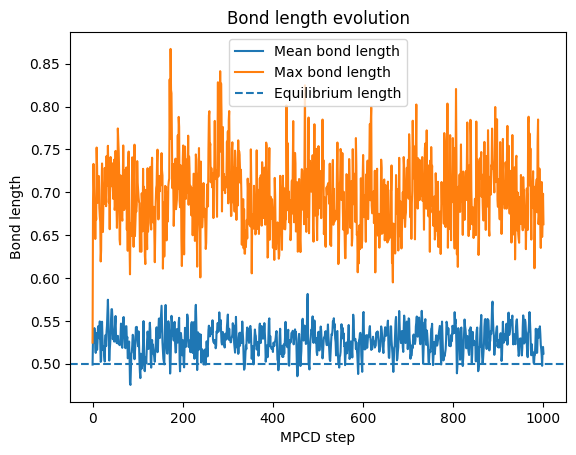

In [377]:
plt.figure()
plt.plot(history["step"], history["mean_bond_length"], label="Mean bond length")
plt.plot(history["step"], history["max_bond_length"], label="Max bond length")
plt.axhline(params["bond_length"], linestyle="--", label="Equilibrium length")
plt.xlabel("MPCD step")
plt.ylabel("Bond length")
plt.title("Bond length evolution")
plt.legend()
plt.show()

## Bond-length distribution: isolated vs coupled

#### Creating an isolated Polymer

In [378]:
isolated_polymer = mpcd.Polymer(
    params["n_monomers"],
    params["box"],
    dt_md,
    params["bond_length"],
    params["polymer_mass"],
    params["k_bond"],
    params["kBT"],
    params["seed"] + 1
)

isolated_polymer.initPositionsRandomWalk()
isolated_polymer.initVelocitiesNormal()

n_md_steps = (
    params["n_mpcd_steps"]
    * params["n_md_substeps"]
)

isolated_bond_vector_every = (
    params["bond_vector_every"]
    * params["n_md_substeps"]
)

isolated_sample_every = 1000

isolated_samples = mpcd.runPolymer(
    isolated_polymer,
    n_md_steps,
    isolated_sample_every,
    0,
    isolated_bond_vector_every
)

In [379]:
coupled_bond_vectors = np.asarray(samples.polymer.bondVectors)
isolated_bond_vectors = np.asarray(isolated_samples.bondVectors)

In [380]:
print(coupled_bond_vectors.shape)
print(isolated_bond_vectors.shape)

(101, 29, 3)
(101, 29, 3)


In [381]:
coupled_bond_lengths = np.linalg.norm(coupled_bond_vectors, axis=2)
isolated_bond_lengths = np.linalg.norm(isolated_bond_vectors, axis=2)

In [382]:
coupled_start = len(coupled_bond_lengths) // 2
isolated_start = len(isolated_bond_lengths) // 2

coupled_bonds_eq = coupled_bond_lengths[coupled_start:].flatten()

isolated_bonds_eq = isolated_bond_lengths[isolated_start:].flatten()

In [383]:
all_bonds = np.concatenate([isolated_bonds_eq, coupled_bonds_eq])

bins = np.linspace(all_bonds.min(), all_bonds.max(), 60)

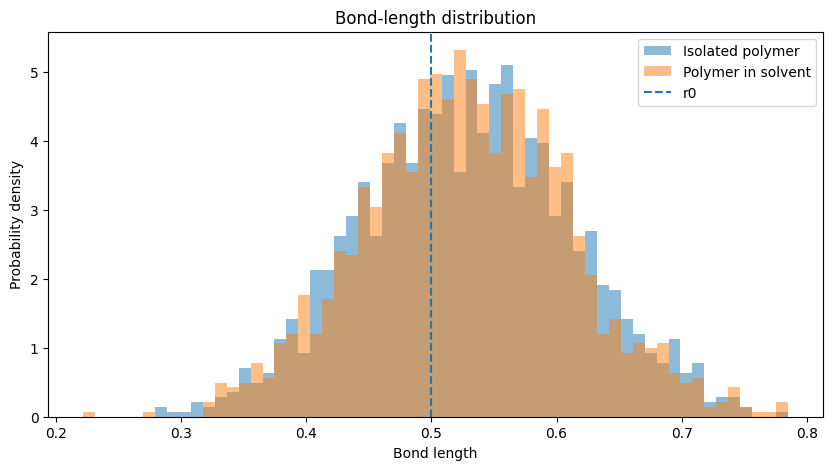

Isolated mean bond length: 0.5288057550585064
Coupled mean bond length: 0.528340066919395
Isolated std: 0.08413739431303596
Coupled std: 0.08199791004785612


In [384]:
plt.figure(figsize=(10, 5))

plt.hist(isolated_bonds_eq, bins=bins, density=True, alpha=0.5, label="Isolated polymer")
plt.hist(coupled_bonds_eq, bins=bins, density=True, alpha=0.5, label="Polymer in solvent")

plt.axvline(params["bond_length"], linestyle="--", label="r0" )

plt.xlabel("Bond length")
plt.ylabel("Probability density")
plt.title("Bond-length distribution")
plt.legend()
plt.show()

print("Isolated mean bond length:", isolated_bonds_eq.mean())
print("Coupled mean bond length:", coupled_bonds_eq.mean())
print("Isolated std:", isolated_bonds_eq.std())
print("Coupled std:", coupled_bonds_eq.std())

Shortest average: 0.48829755433069455/nLongest average0.5670282635641616/nDifference: 0.07873070923346703


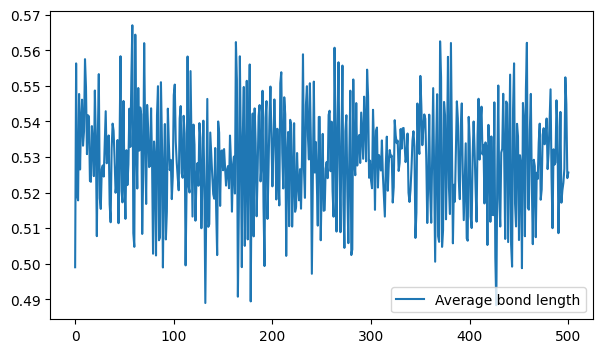

In [385]:
average = np.asarray(isolated_samples.averageBondLength)
print(f"Shortest average: {average.min()}/nLongest average{average.max()}/nDifference: {average.max() - average.min()}")

plt.figure(figsize=(7, 4))
plt.plot(average, label="Average bond length")
plt.legend()
plt.show()

#### Dependence on polymer length

In [386]:
polymer_lengths = [10, 20, 30, 50, 80]
n_repeats = 5


In [387]:
def run_coupled_for_length(n_monomers, seed):
    print(
        "Running:",
        "N =", n_monomers,
        "steps =", params["n_mpcd_steps"]
    )

    system = mpcd.System(
        params["n_solvent"],
        params["box"],
        params["a"],
        params["h"],
        params["solvent_mass"],
        params["kBT"],
        params["alpha"],
        seed
    )

    polymer = mpcd.Polymer(
        n_monomers,
        params["box"],
        dt_md,
        params["bond_length"],
        params["polymer_mass"],
        params["k_bond"],
        params["kBT"],
        seed + 1
    )

    system.initPositionsUniform()
    system.initVelocitiesNormal()

    polymer.initPositionsRandomWalk()
    polymer.initVelocitiesNormal()

    samples = mpcd.runCoupled(
        system,
        polymer,
        params["n_mpcd_steps"],
        params["sample_every"],
        0,
        0
    )

    return samples

In [388]:
def run_and_summarize(n_monomers, seed):
    system = mpcd.System(
        params["n_solvent"],
        params["box"],
        params["a"],
        params["h"],
        params["solvent_mass"],
        params["kBT"],
        params["alpha"],
        seed
    )

    polymer = mpcd.Polymer(
        n_monomers,
        params["box"],
        dt_md,
        params["bond_length"],
        params["polymer_mass"],
        params["k_bond"],
        params["kBT"],
        seed + 1
    )

    system.initPositionsUniform()
    system.initVelocitiesNormal()

    polymer.initPositionsRandomWalk()
    polymer.initVelocitiesNormal()

    samples = mpcd.runCoupled(
        system,
        polymer,
        params["n_mpcd_steps"],
        params["sample_every"],
        0,
        0
    )

    polymer_K = np.asarray(samples.polymer.kineticEnergy)
    polymer_E = np.asarray(samples.polymer.totalEnergy)
    mean_bond_length = np.asarray(samples.polymer.averageBondLength)
    polymer_momentum = np.asarray(samples.polymer.momentum)
    solvent_T = np.asarray(samples.solvent.temperature)
    polymer_U = np.asarray(samples.polymer.potentialEnergy)

    start = len(polymer_E) // 2

    P2 = np.sum(
        polymer_momentum**2,
        axis=1
    )

    K_com = P2 / (
        2.0
        * n_monomers
        * params["polymer_mass"]
    )

    K_internal = (
        polymer_K
        - K_com
    )

    polymer_T = (
        2.0
        * K_internal
        / (3.0 * (n_monomers - 1))
    )

    E_eq = polymer_E[start:]

    return {
        "N": n_monomers,
        "mean_bond_length": mean_bond_length[start:].mean(),
        "energy_per_monomer": E_eq.mean() / n_monomers,
        "relative_energy_fluctuation": E_eq.std() / E_eq.mean(),
        "kinetic_energy_per_monomer": polymer_K[start:].mean() / n_monomers,
        "potential_energy_per_monomer": polymer_U[start:].mean() / n_monomers,
        "potential_energy_per_bond": polymer_U[start:].mean() / (n_monomers - 1),
        "polymer_temperature": polymer_T[start:].mean(),
        "polymer_temperature_std": polymer_T[start:].std(),
        "solvent_temperature": solvent_T[start:].mean(),
        
    }

In [389]:
import time

length_results = []

start_total = time.perf_counter()

for N in polymer_lengths:
    for repeat in range(n_repeats):
        seed = params["seed"] + 1000*repeat + N
        start = time.perf_counter()
        result = run_and_summarize(N, seed)
        result["repeat"] = repeat
        length_results.append(result)
        elapsed = time.perf_counter() - start
        print(
            f"N = {N}, "
            f"repeat = {repeat + 1}/{n_repeats}, "
            f"time = {elapsed:.3f} s"
        )

print(
    "Total time:",
    time.perf_counter() - start_total
)

N = 10, repeat = 1/5, time = 0.163 s
N = 10, repeat = 2/5, time = 0.140 s
N = 10, repeat = 3/5, time = 0.136 s
N = 10, repeat = 4/5, time = 0.140 s
N = 10, repeat = 5/5, time = 0.139 s
N = 20, repeat = 1/5, time = 0.190 s
N = 20, repeat = 2/5, time = 0.175 s
N = 20, repeat = 3/5, time = 0.178 s
N = 20, repeat = 4/5, time = 0.178 s
N = 20, repeat = 5/5, time = 0.175 s
N = 30, repeat = 1/5, time = 0.205 s
N = 30, repeat = 2/5, time = 0.212 s
N = 30, repeat = 3/5, time = 0.210 s
N = 30, repeat = 4/5, time = 0.209 s
N = 30, repeat = 5/5, time = 0.231 s
N = 50, repeat = 1/5, time = 0.280 s
N = 50, repeat = 2/5, time = 0.284 s
N = 50, repeat = 3/5, time = 0.280 s
N = 50, repeat = 4/5, time = 0.296 s
N = 50, repeat = 5/5, time = 0.265 s
N = 80, repeat = 1/5, time = 0.377 s
N = 80, repeat = 2/5, time = 0.364 s
N = 80, repeat = 3/5, time = 0.374 s
N = 80, repeat = 4/5, time = 0.386 s
N = 80, repeat = 5/5, time = 0.383 s
Total time: 5.970820666999316


In [390]:
import pandas as pd

length_df = pd.DataFrame(
    length_results
)

length_df

,N,mean_bond_length,energy_per_monomer,relative_energy_fluctuation,kinetic_energy_per_monomer,potential_energy_per_monomer,potential_energy_per_bond,polymer_temperature,polymer_temperature_std,solvent_temperature,repeat
0,10,0.533248,1.546740,0.199446,1.163595,0.383145,0.425716,0.773187,0.204523,0.750091,0
1,10,0.528742,1.421616,0.215138,1.081397,0.340220,0.378022,0.719512,0.182579,0.761490,1
2,10,0.526445,1.567530,0.195514,1.207080,0.360450,0.400500,0.803743,0.192685,0.756474,2
3,10,0.529772,1.502824,0.206398,1.134940,0.367884,0.408760,0.765315,0.193587,0.749197,3
4,10,0.527260,1.562951,0.201303,1.180832,0.382119,0.424577,0.796110,0.195886,0.743470,4
5,20,0.527502,1.443569,0.129231,1.081866,0.361703,0.380740,0.722781,0.122652,0.744316,0
6,20,0.526904,1.459474,0.143574,1.098012,0.361462,0.380486,0.729508,0.128638,0.746914,1
7,20,0.525060,1.456581,0.143046,1.093951,0.362630,0.381716,0.729021,0.133411,0.738917,2
8,20,0.528604,1.513033,0.117620,1.131348,0.381684,0.401773,0.757520,0.117220,0.756294,3
9,20,0.528750,1.404393,0.142291,1.053896,0.350497,0.368944,0.699417,0.122717,0.735114,4


In [391]:
length_summary = (
    length_df
    .groupby("N")
    .agg(
        mean_bond_length=(
            "mean_bond_length",
            "mean"
        ),

        mean_bond_length_repeat_std=(
            "mean_bond_length",
            "std"
        ),

        energy_per_monomer=(
            "energy_per_monomer",
            "mean"
        ),

        energy_per_monomer_repeat_std=(
            "energy_per_monomer",
            "std"
        ),

        relative_energy_fluctuation=(
            "relative_energy_fluctuation",
            "mean"
        ),

        relative_energy_fluctuation_repeat_std=(
            "relative_energy_fluctuation",
            "std"
        ),
        
        kinetic_energy_per_monomer=(
            "kinetic_energy_per_monomer",
            "mean"
        ),

        kinetic_energy_per_monomer_repeat_std=(
            "kinetic_energy_per_monomer",
            "std"
        ),

        potential_energy_per_monomer=(
            "potential_energy_per_monomer",
            "mean"
        ),

        potential_energy_per_monomer_repeat_std=(
            "potential_energy_per_monomer",
            "std"
        ),

        potential_energy_per_bond=(
            "potential_energy_per_bond",
            "mean"
        ),

        polymer_temperature=(
            "polymer_temperature",
            "mean"
        ),

        polymer_temperature_repeat_std=(
            "polymer_temperature",
            "std"
        ),

        polymer_temperature_fluctuation=(
            "polymer_temperature_std",
            "mean"
        ),

        solvent_temperature=(
            "solvent_temperature",
            "mean"
        ),
    )
    .reset_index()
)

length_summary

,N,mean_bond_length,mean_bond_length_repeat_std,energy_per_monomer,energy_per_monomer_repeat_std,relative_energy_fluctuation,relative_energy_fluctuation_repeat_std,kinetic_energy_per_monomer,kinetic_energy_per_monomer_repeat_std,potential_energy_per_monomer,potential_energy_per_monomer_repeat_std,potential_energy_per_bond,polymer_temperature,polymer_temperature_repeat_std,polymer_temperature_fluctuation,solvent_temperature
0,10,0.529093,0.002656,1.520332,0.060813,0.203560,0.007564,1.153569,0.048122,0.366764,0.017677,0.407515,0.771573,0.033125,0.193852,0.752144
1,20,0.527364,0.001500,1.455410,0.038991,0.135152,0.011474,1.091815,0.028030,0.363595,0.011268,0.382732,0.727649,0.020727,0.124928,0.744311
2,30,0.528641,0.001468,1.498877,0.053630,0.126020,0.010461,1.118292,0.040394,0.380585,0.014229,0.393709,0.746623,0.028390,0.110239,0.750771
3,50,0.528303,0.001805,1.529714,0.069003,0.086543,0.015082,1.142617,0.050815,0.387097,0.018579,0.394997,0.761524,0.034273,0.081976,0.748959
4,80,0.530455,0.000618,1.539318,0.029895,0.066942,0.007560,1.139423,0.022480,0.399895,0.007931,0.404957,0.759297,0.014823,0.062251,0.749330


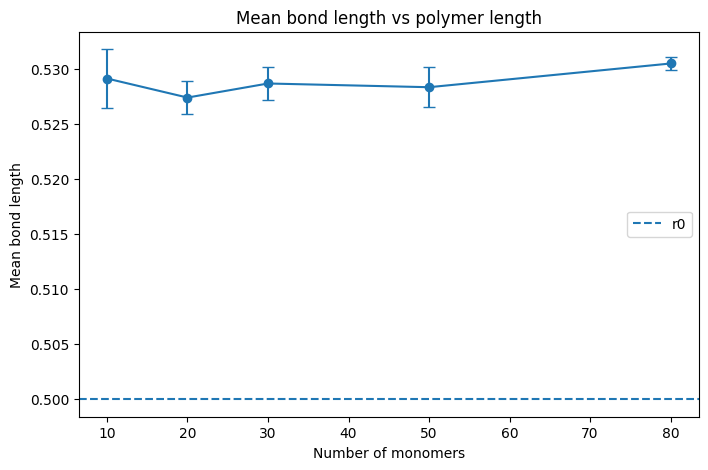

In [392]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    length_summary["N"],
    length_summary["mean_bond_length"],
    yerr=length_summary["mean_bond_length_repeat_std"],
    marker="o",
    capsize=4
)

plt.axhline(
    params["bond_length"],
    linestyle="--",
    label="r0"
)

plt.xlabel("Number of monomers")
plt.ylabel("Mean bond length")
plt.title("Mean bond length vs polymer length")
plt.legend()
plt.show()

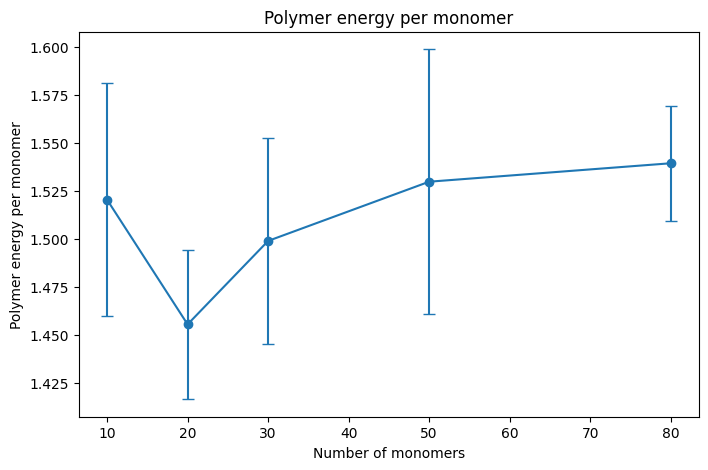

In [393]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    length_summary["N"],
    length_summary["energy_per_monomer"],
    yerr=length_summary["energy_per_monomer_repeat_std"],
    marker="o",
    capsize=4
)

plt.xlabel("Number of monomers")
plt.ylabel("Polymer energy per monomer")
plt.title("Polymer energy per monomer")
plt.show()

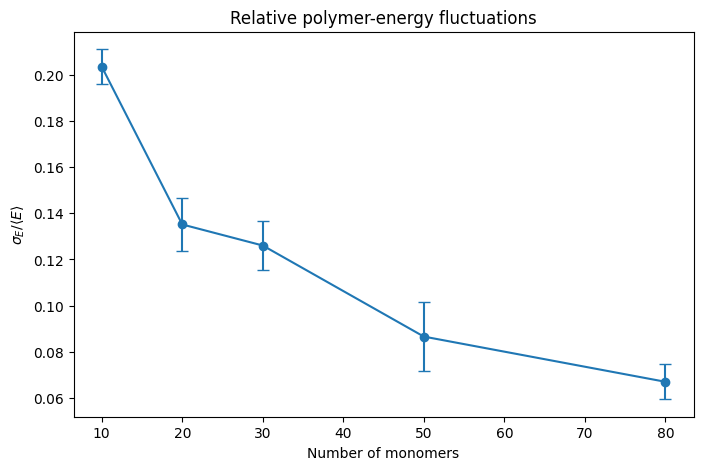

In [396]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    length_summary["N"],
    length_summary["relative_energy_fluctuation"],
    yerr=length_summary["relative_energy_fluctuation_repeat_std"],
    marker="o",
    capsize=4
)

plt.xlabel("Number of monomers")
plt.ylabel(
    r"$\sigma_E / \langle E \rangle$"
)

plt.title(
    "Relative polymer-energy fluctuations"
)

plt.show()

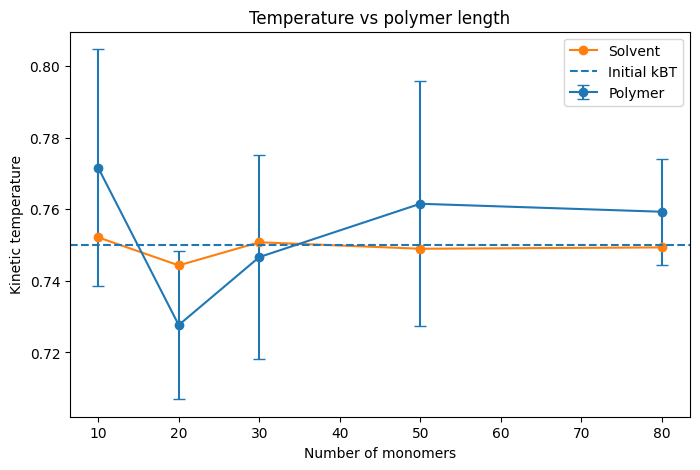

In [397]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    length_summary["N"],
    length_summary["polymer_temperature"],
    yerr=length_summary["polymer_temperature_repeat_std"],
    marker="o",
    capsize=4,
    label="Polymer"
)

plt.plot(
    length_summary["N"],
    length_summary["solvent_temperature"],
    marker="o",
    label="Solvent"
)

plt.axhline(
    params["kBT"],
    linestyle="--",
    label="Initial kBT"
)

plt.xlabel("Number of monomers")
plt.ylabel("Kinetic temperature")
plt.title("Temperature vs polymer length")
plt.legend()
plt.show()

## Extras

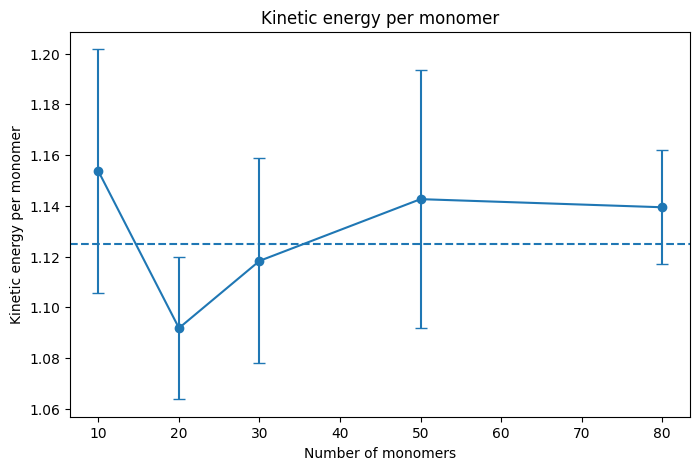

In [394]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    length_summary["N"],
    length_summary["kinetic_energy_per_monomer"],
    yerr=length_summary["kinetic_energy_per_monomer_repeat_std"],
    marker="o",
    capsize=4
)

plt.axhline(
    1.5 * params["kBT"],
    linestyle="--",
    label=r"$3k_BT/2$"
)

plt.xlabel("Number of monomers")
plt.ylabel("Kinetic energy per monomer")
plt.title("Kinetic energy per monomer")
plt.show()

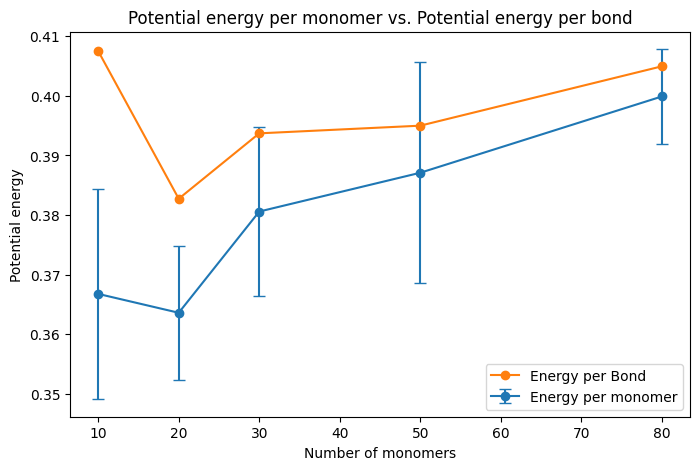

In [395]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    length_summary["N"],
    length_summary["potential_energy_per_monomer"],
    yerr=length_summary["potential_energy_per_monomer_repeat_std"],
    label="Energy per monomer",
    marker="o",
    capsize=4
)

plt.plot(
    length_summary["N"],
    length_summary["potential_energy_per_bond"],
    #yerr=length_summary["potential_energy_per_monomer_repeat_std"],
    marker="o",
    label="Energy per Bond",
    #capsize=4
)



plt.xlabel("Number of monomers")
plt.ylabel("Potential energy")
plt.title("Potential energy per monomer vs. Potential energy per bond")
plt.legend()
plt.show()